<a href="https://colab.research.google.com/github/ashabb-ipl/iplCapstoneForPredictiveAI/blob/main/Final_AnomalyDetection_Final_ForDemo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Start

DataFrame 'df' created with columns: ['sensor_1', 'sensor_2']
First 5 rows of df:
    sensor_1   sensor_2
0  70.208858  57.623909
1  70.157100  56.462869
2  70.106100  58.473041
3  70.405754  58.996938
4  69.920349  57.825536


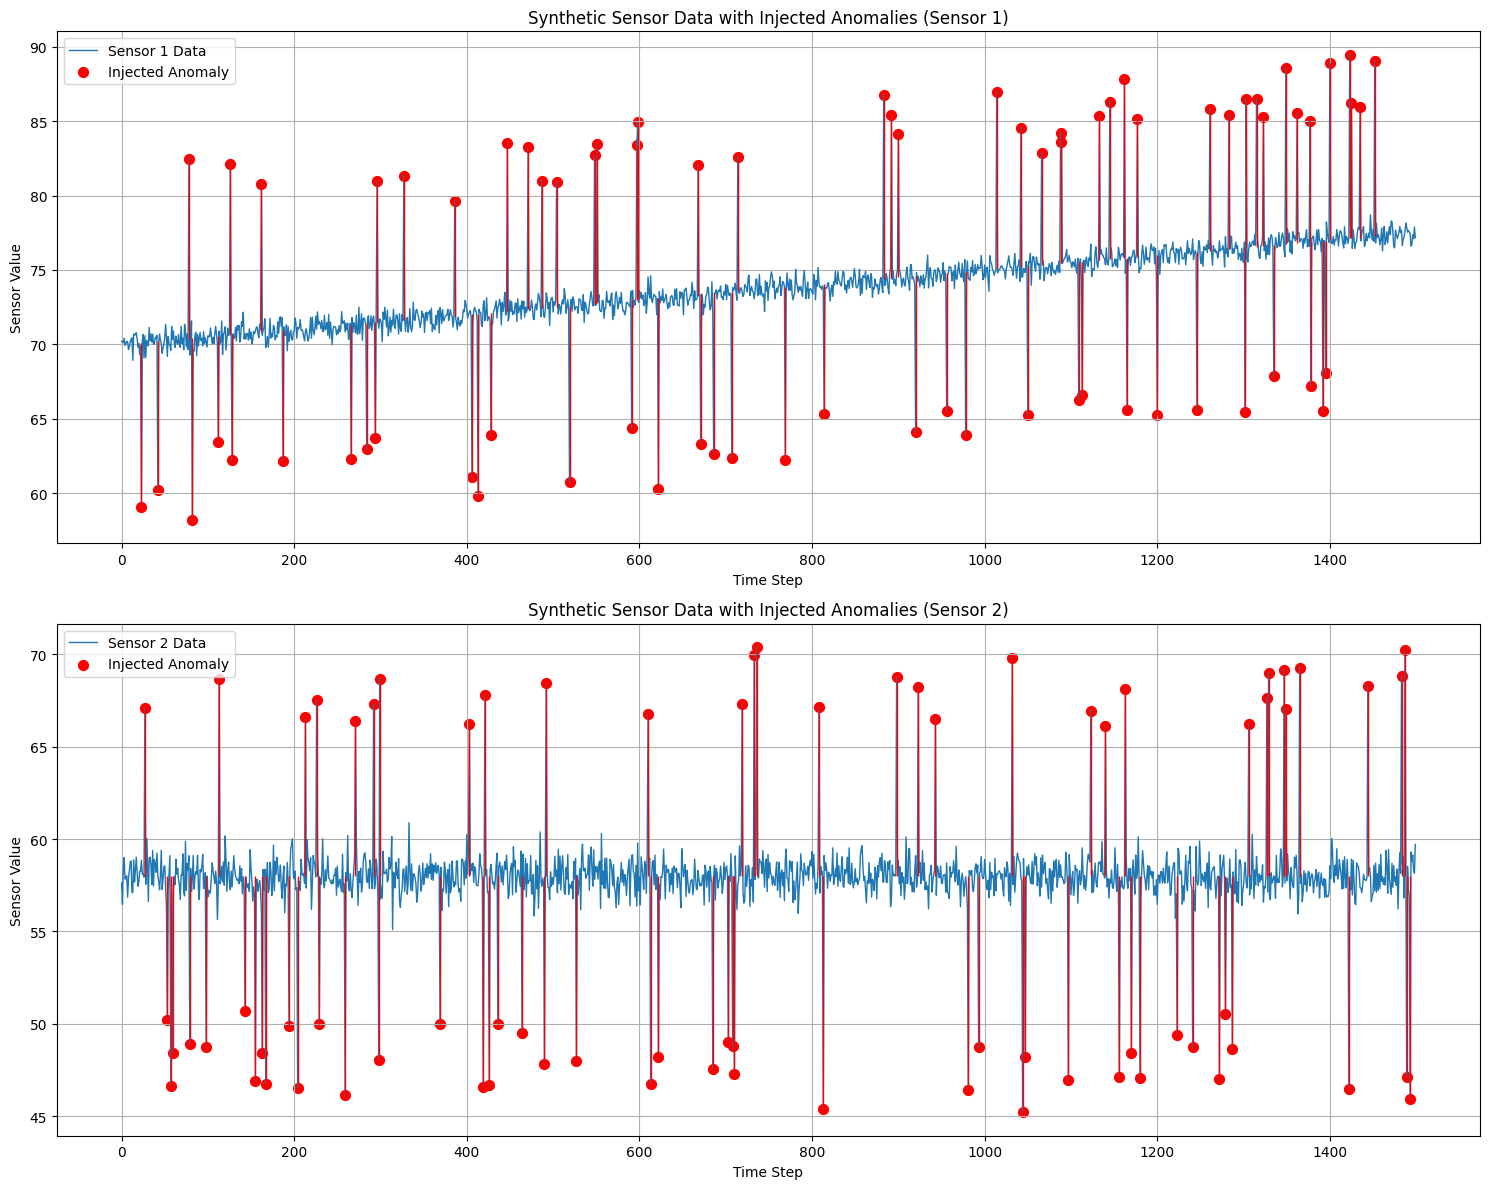

Synthetic data generation complete. Variables 'sensor_1_data', 'sensor_2_data', 'injected_anomaly_indices_1', and 'injected_anomaly_indices_2' are now defined.


In [1]:
# filename: data_generation_script.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Parameters for Synthetic Data Generation ---
N_SAMPLES = 1500  # Total number of time steps
BASE_VALUE_1 = 70 # Base value for Sensor 1
BASE_VALUE_2 = 58 # Base value for Sensor 2
TREND_SLOPE_1 = 0.005 # Slight upward trend for Sensor 1
NOISE_LEVEL = 0.5 # Random noise level
NUM_ANOMALIES = 75 # Number of anomalies to inject (approx 5% of N_SAMPLES)
ANOMALY_MAGNITUDE = 10 # How much anomalies deviate from the normal

# --- Generate Synthetic Sensor 1 Data ---
time_steps = np.arange(N_SAMPLES)
sensor_1_data = BASE_VALUE_1 + (TREND_SLOPE_1 * time_steps) + np.random.normal(0, NOISE_LEVEL, N_SAMPLES)

# --- Inject Anomalies into Sensor 1 ---
injected_anomaly_indices_1 = np.random.choice(N_SAMPLES, NUM_ANOMALIES, replace=False)
for idx in injected_anomaly_indices_1:
    # Randomly make anomaly a spike or a dip
    if np.random.rand() > 0.5:
        sensor_1_data[idx] += ANOMALY_MAGNITUDE * np.random.uniform(0.8, 1.2) # Spike
    else:
        sensor_1_data[idx] -= ANOMALY_MAGNITUDE * np.random.uniform(0.8, 1.2) # Dip

# --- Generate Synthetic Sensor 2 Data ---
# Sensor 2 will be more stable, less trend
sensor_2_data = BASE_VALUE_2 + np.random.normal(0, NOISE_LEVEL * 1.5, N_SAMPLES) # Slightly more noise for variety

# --- Inject Anomalies into Sensor 2 ---
injected_anomaly_indices_2 = np.random.choice(N_SAMPLES, NUM_ANOMALIES, replace=False)
for idx in injected_anomaly_indices_2:
    if np.random.rand() > 0.5:
        sensor_2_data[idx] += ANOMALY_MAGNITUDE * np.random.uniform(0.8, 1.2)
    else:
        sensor_2_data[idx] -= ANOMALY_MAGNITUDE * np.random.uniform(0.8, 1.2)

# --- CREATE THE 'df' DATAFRAME HERE ---
# This is the crucial addition!
df = pd.DataFrame({
    'sensor_1': sensor_1_data,
    'sensor_2': sensor_2_data
}, index=time_steps) # Using time_steps as the index

print("DataFrame 'df' created with columns:", df.columns.tolist())
print("First 5 rows of df:")
print(df.head())

# --- Plot the Generated Data ---
plt.figure(figsize=(15, 12))

# Plot for Sensor 1
plt.subplot(2, 1, 1)
plt.plot(time_steps, sensor_1_data, label='Sensor 1 Data', linewidth=1)
plt.scatter(injected_anomaly_indices_1, sensor_1_data[injected_anomaly_indices_1],
            color='red', s=50, label='Injected Anomaly')
for idx in injected_anomaly_indices_1:
    plt.vlines(idx,
               min(sensor_1_data[idx], BASE_VALUE_1 + (TREND_SLOPE_1 * idx)),
               max(sensor_1_data[idx], BASE_VALUE_1 + (TREND_SLOPE_1 * idx)),
               color='red', linestyle='-', linewidth=1)
plt.title('Synthetic Sensor Data with Injected Anomalies (Sensor 1)')
plt.xlabel('Time Step')
plt.ylabel('Sensor Value')
plt.grid(True)
plt.legend()

# Plot for Sensor 2
plt.subplot(2, 1, 2)
plt.plot(time_steps, sensor_2_data, label='Sensor 2 Data', linewidth=1)
plt.scatter(injected_anomaly_indices_2, sensor_2_data[injected_anomaly_indices_2],
            color='red', s=50, label='Injected Anomaly')
for idx in injected_anomaly_indices_2:
    plt.vlines(idx,
               min(sensor_2_data[idx], BASE_VALUE_2),
               max(sensor_2_data[idx], BASE_VALUE_2),
               color='red', linestyle='-', linewidth=1)
plt.title('Synthetic Sensor Data with Injected Anomalies (Sensor 2)')
plt.xlabel('Time Step')
plt.ylabel('Sensor Value')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("Synthetic data generation complete. Variables 'sensor_1_data', 'sensor_2_data', 'injected_anomaly_indices_1', and 'injected_anomaly_indices_2' are now defined.")

Building robust peer-aware features (window=51)...
  Using Median + MAD (robust to anomalies in window)...
  Features built successfully!

--- Feature Separation Diagnostics ---
  Sensor 1 Robust Z-Score:
    Normal  — mean: 0.751  max: 3.585
    Anomaly — mean: 10.115  max: 34.276
  Sensor 2 Robust Z-Score:
    Normal  — mean: 0.771  max: 3.929
    Anomaly — mean: 6.595  max: 21.181

Training IsolationForest...
Training complete!

  AUTO-LEARNING OPTIMAL THRESHOLD (WITH FLOOR CONSTRAINT)
  Search range : 0.50 → 22.47

  ✅ Optimal threshold (auto-learned) : 3.6259
     Best F1                          : 0.9966
     Precision at best threshold      : 1.0000
     Recall at best threshold         : 0.9932


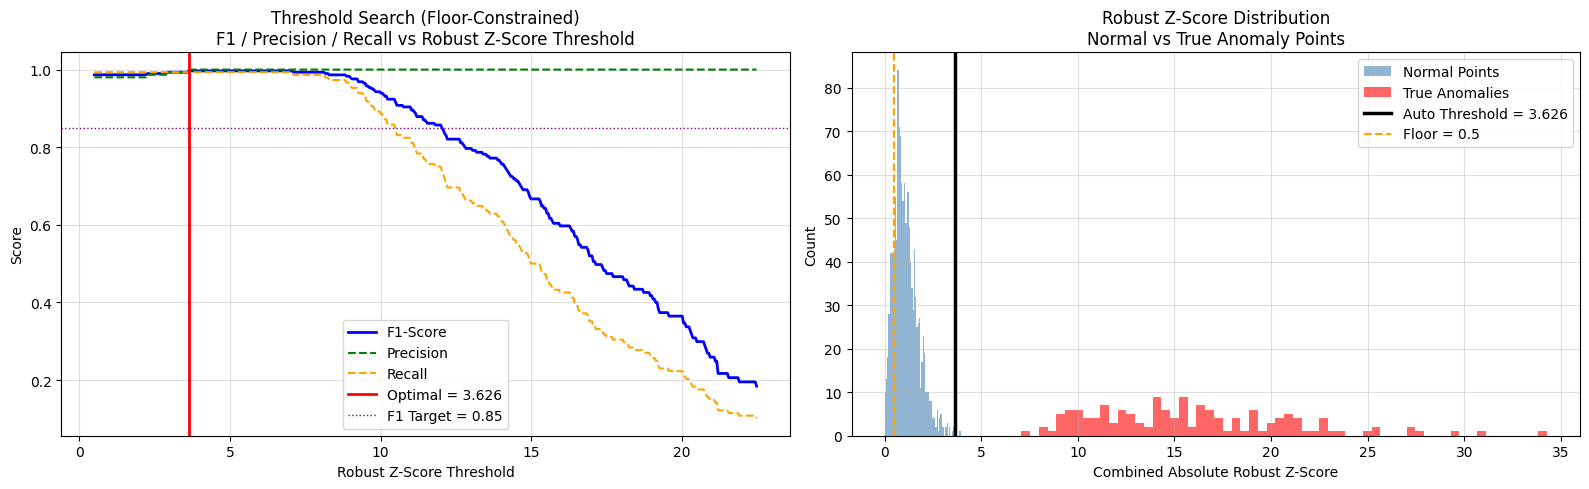


        FINAL EVALUATION vs QUALITY TARGETS
Metric         Achieved     Target     Status
------------------------------------------------------------
Precision        1.0000       0.85     ✅ PASS
Recall           0.9932       0.85     ✅ PASS
F1-Score         0.9966       0.85     ✅ PASS
AUC-ROC          0.9997       0.90     ✅ PASS

  TP : 147  |  FP : 0  |  TN : 1352  |  FN : 1


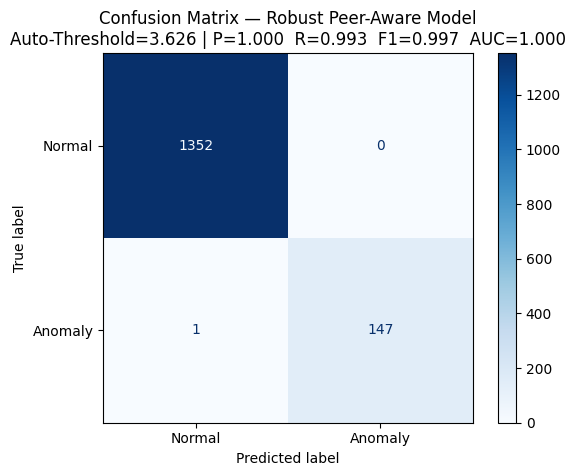


✅ All required columns present in Predictions sheet:
   • Sensor_1_Value            — sample value: 70.20885757821365
   • Sensor_2_Value            — sample value: 57.623908831786196
   • True_Anomaly              — sample value: 0
   • Predicted_Anomaly         — sample value: 0
   • Anomaly_Score             — sample value: -0.10685229482226616
   • Is_Correct_Prediction     — sample value: True
   • Prediction_Type           — sample value: TN

✅ Excel saved : anomaly_reports/anomaly_detection_report.xlsx
   Sheet 1 — Training Data   : 1500 rows × 2 sensor columns
   Sheet 2 — Predictions     : 1500 rows × 10 columns
   Sheet 3 — Quality Metrics : Summary scores & pass/fail

--- Predictions Sheet Preview (first 5 rows) ---
           Sensor_1_Value  Sensor_2_Value  True_Anomaly  Predicted_Anomaly  Anomaly_Score  Is_Correct_Prediction Prediction_Type
Time_Step                                                                                                                       
0   

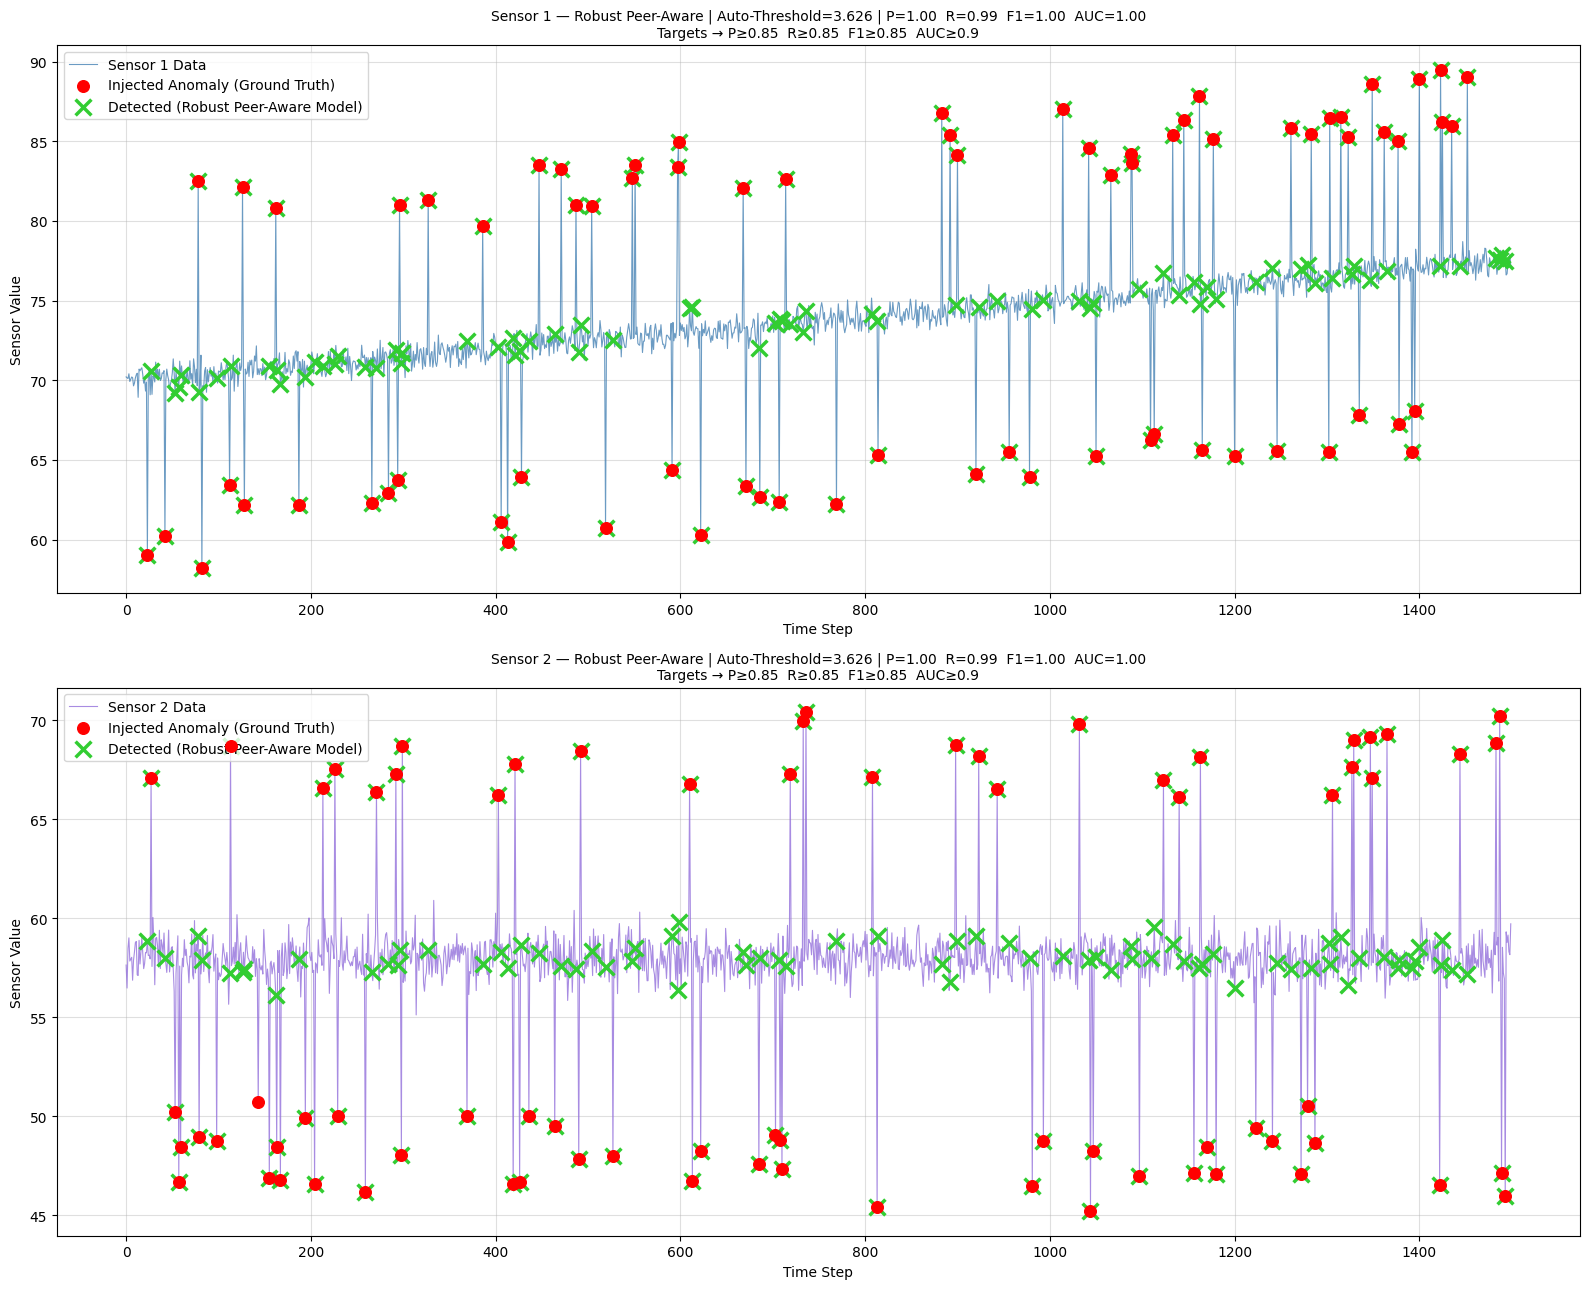

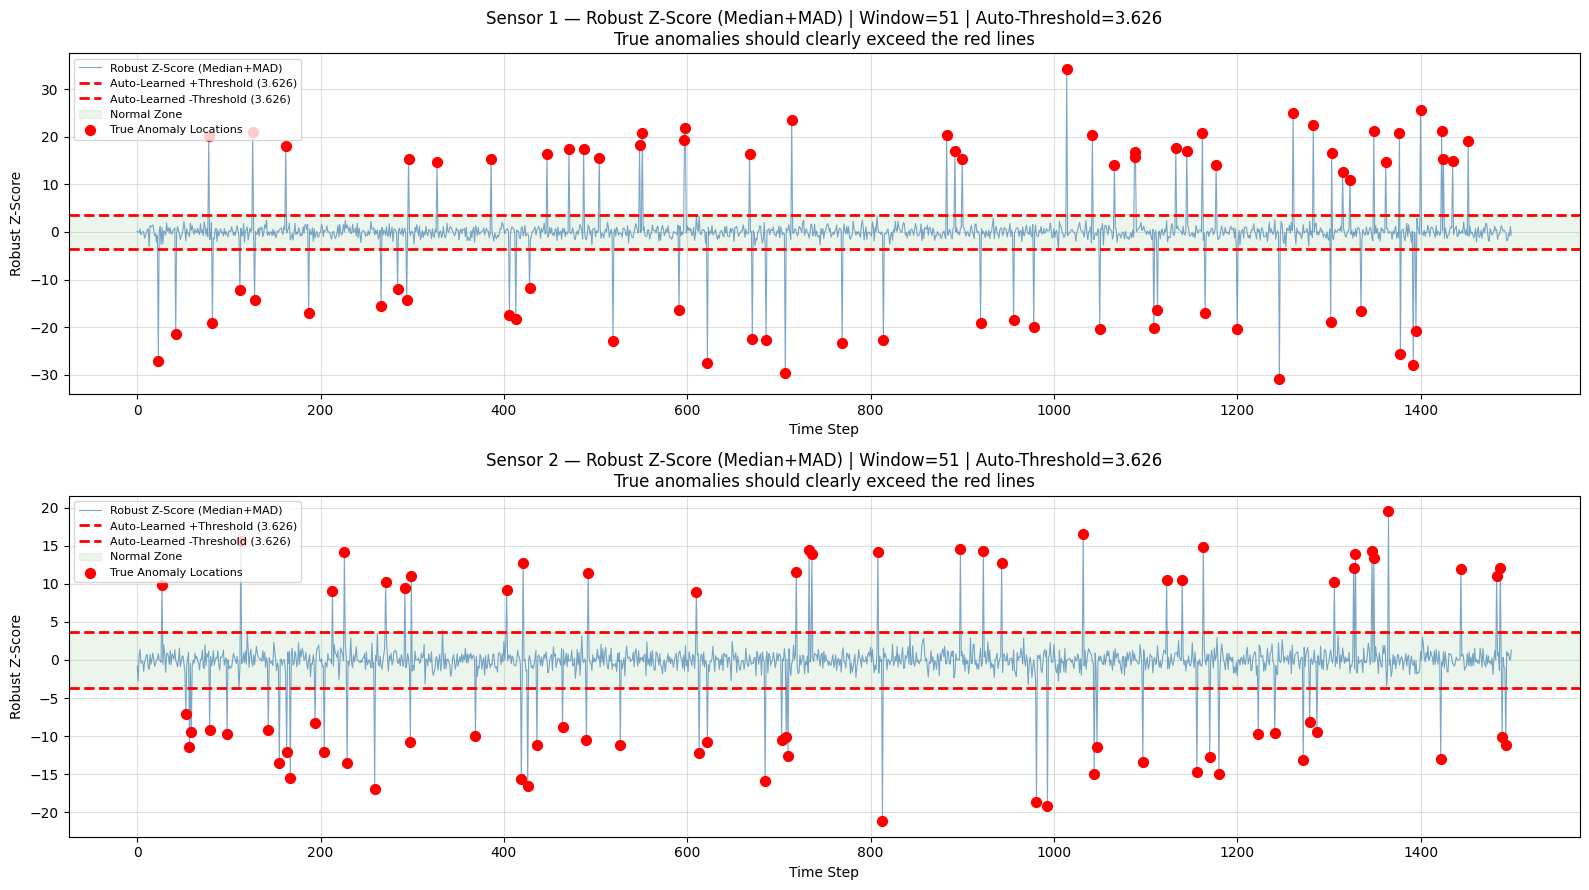

In [2]:
# filename: anomaly_detection_robust.py
# FIX: Predictions sheet now contains all required columns:
# Sensor_1_Value, Sensor_2_Value, True_Anomaly, Predicted_Anomaly,
# Anomaly_Score, Is_Correct_Prediction, Prediction_Type

import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
from datetime import datetime
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

# ===========================================================
# CONFIGURATION
# ===========================================================
REPORTS_DIR        = 'anomaly_reports'
RANDOM_STATE       = 42
CONTAMINATION_RATE = 0.10 #0.06
ROLLING_WINDOW     = 51
THRESHOLD_FLOOR    = 0.5
THRESHOLD_CEILING  = None

TARGET_PRECISION   = 0.85
TARGET_RECALL      = 0.85
TARGET_F1          = 0.85
TARGET_AUC_ROC     = 0.90

os.makedirs(REPORTS_DIR, exist_ok=True)

# ===========================================================
# STEP 1: ROBUST PEER-AWARE FEATURE ENGINEERING
# ===========================================================

def build_robust_peer_features(sensor_data, window=51):
    s = pd.Series(sensor_data)

    peer_median = s.rolling(
        window=window, center=True, min_periods=5
    ).median()

    def rolling_mad(series, w):
        def mad_func(x):
            med = np.median(x)
            return np.median(np.abs(x - med))
        return series.rolling(
            window=w, center=True, min_periods=5
        ).apply(mad_func, raw=True)

    peer_mad            = rolling_mad(s, window).fillna(1)
    peer_mad_scaled     = (peer_mad * 1.4826)
    peer_mad_scaled     = peer_mad_scaled.replace(0, peer_mad_scaled.median())

    peer_median_arr     = peer_median.values
    peer_mad_scaled_arr = peer_mad_scaled.values

    robust_zscore       = (sensor_data - peer_median_arr) / peer_mad_scaled_arr
    abs_robust_zscore   = np.abs(robust_zscore)

    rate_of_change      = np.diff(sensor_data, prepend=sensor_data[0])
    roc_mad_series      = rolling_mad(pd.Series(rate_of_change), window).fillna(1)
    roc_mad_arr         = roc_mad_series.values * 1.4826
    roc_zscore          = (
        (rate_of_change - np.median(rate_of_change)) / roc_mad_arr
    )

    peer_min            = s.rolling(window=window, center=True, min_periods=5).min()
    peer_max            = s.rolling(window=window, center=True, min_periods=5).max()
    peer_range          = (peer_max - peer_min).replace(0, 1)
    peer_min_arr        = peer_min.values
    peer_range_arr      = peer_range.values
    percentile_rank     = (sensor_data - peer_min_arr) / peer_range_arr

    return {
        'robust_zscore'    : robust_zscore,
        'abs_robust_zscore': abs_robust_zscore,
        'peer_median'      : peer_median_arr,
        'peer_mad_scaled'  : peer_mad_scaled_arr,
        'roc_zscore'       : roc_zscore,
        'percentile_rank'  : percentile_rank,
        'rate_of_change'   : rate_of_change,
    }

print(f"Building robust peer-aware features (window={ROLLING_WINDOW})...")
print("  Using Median + MAD (robust to anomalies in window)...")
feats_1 = build_robust_peer_features(sensor_1_data, window=ROLLING_WINDOW)
feats_2 = build_robust_peer_features(sensor_2_data, window=ROLLING_WINDOW)
print("  Features built successfully!")

# ===========================================================
# GROUND TRUTH
# ===========================================================

true_combined = np.array(
    sorted(list(set(injected_anomaly_indices_1) | set(injected_anomaly_indices_2)))
)
y_true = np.zeros(N_SAMPLES, dtype=int)
y_true[true_combined] = 1

normal_mask  = (y_true == 0)
anomaly_mask = (y_true == 1)

print("\n--- Feature Separation Diagnostics ---")
for label, feats in [('Sensor 1', feats_1), ('Sensor 2', feats_2)]:
    normal_z  = np.abs(feats['robust_zscore'][normal_mask])
    anomaly_z = np.abs(feats['robust_zscore'][anomaly_mask])
    print(f"  {label} Robust Z-Score:")
    print(f"    Normal  — mean: {normal_z.mean():.3f}  max: {normal_z.max():.3f}")
    print(f"    Anomaly — mean: {anomaly_z.mean():.3f}  max: {anomaly_z.max():.3f}")

# ===========================================================
# BUILD FEATURE DATAFRAME
# ===========================================================

data_for_model = pd.DataFrame({
    'Sensor_1_Value'      : sensor_1_data,
    'Sensor_2_Value'      : sensor_2_data,
    'S1_Robust_ZScore'    : feats_1['robust_zscore'],
    'S2_Robust_ZScore'    : feats_2['robust_zscore'],
    'S1_Abs_Robust_ZScore': feats_1['abs_robust_zscore'],
    'S2_Abs_Robust_ZScore': feats_2['abs_robust_zscore'],
    'S1_ROC_ZScore'       : feats_1['roc_zscore'],
    'S2_ROC_ZScore'       : feats_2['roc_zscore'],
    'S1_Percentile_Rank'  : feats_1['percentile_rank'],
    'S2_Percentile_Rank'  : feats_2['percentile_rank'],
    'S1_Peer_MAD'         : feats_1['peer_mad_scaled'],
    'S2_Peer_MAD'         : feats_2['peer_mad_scaled'],
})

features_to_use = [
    'S1_Robust_ZScore',    'S2_Robust_ZScore',
    'S1_Abs_Robust_ZScore','S2_Abs_Robust_ZScore',
    'S1_ROC_ZScore',       'S2_ROC_ZScore',
    'S1_Percentile_Rank',  'S2_Percentile_Rank',
    'S1_Peer_MAD',         'S2_Peer_MAD',
]

scaler       = StandardScaler()
scaled_array = scaler.fit_transform(data_for_model[features_to_use])
scaled_df    = pd.DataFrame(scaled_array, columns=features_to_use)

# ===========================================================
# STEP 2: TRAIN ISOLATION FOREST
# ===========================================================

model = IsolationForest(
    n_estimators=500,
    contamination=CONTAMINATION_RATE,
    max_samples=256,
    max_features=0.8,
    bootstrap=True,
    random_state=RANDOM_STATE
)

print(f"\nTraining IsolationForest...")
model.fit(scaled_df)
print("Training complete!")

data_for_model['anomaly_score']    = model.decision_function(scaled_df)
data_for_model['model_prediction'] = model.predict(scaled_df)

# ===========================================================
# STEP 3: AUTO-LEARN THRESHOLD WITH FLOOR CONSTRAINT
# ===========================================================

combined_abs_zscore   = np.maximum(
    feats_1['abs_robust_zscore'],
    feats_2['abs_robust_zscore']
)
THRESHOLD_CEILING     = float(np.percentile(combined_abs_zscore, 99))

print("\n" + "="*60)
print("  AUTO-LEARNING OPTIMAL THRESHOLD (WITH FLOOR CONSTRAINT)")
print("="*60)
print(f"  Search range : {THRESHOLD_FLOOR:.2f} → {THRESHOLD_CEILING:.2f}")

candidate_thresholds  = np.linspace(THRESHOLD_FLOOR, THRESHOLD_CEILING, 500)
best_threshold        = THRESHOLD_FLOOR
best_f1               = -1
best_precision        = 0
best_recall           = 0
threshold_results     = []
model_flags           = (data_for_model['model_prediction'] == -1)

for thresh in candidate_thresholds:
    zscore_gate  = combined_abs_zscore > thresh
    y_pred_trial = np.where(model_flags & zscore_gate, 1, 0)

    if y_pred_trial.sum() == 0:
        continue

    p = precision_score(y_true, y_pred_trial, zero_division=0)
    r = recall_score(y_true, y_pred_trial, zero_division=0)
    f = f1_score(y_true, y_pred_trial, zero_division=0)

    threshold_results.append({
        'threshold': thresh, 'precision': p, 'recall': r, 'f1': f
    })

    if f > best_f1:
        best_f1        = f
        best_threshold = thresh
        best_precision = p
        best_recall    = r

threshold_df = pd.DataFrame(threshold_results)

print(f"\n  ✅ Optimal threshold (auto-learned) : {best_threshold:.4f}")
print(f"     Best F1                          : {best_f1:.4f}")
print(f"     Precision at best threshold      : {best_precision:.4f}")
print(f"     Recall at best threshold         : {best_recall:.4f}")

# --- Threshold search plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(threshold_df['threshold'], threshold_df['f1'],
             color='blue',   linewidth=2,   label='F1-Score')
axes[0].plot(threshold_df['threshold'], threshold_df['precision'],
             color='green',  linewidth=1.5, linestyle='--', label='Precision')
axes[0].plot(threshold_df['threshold'], threshold_df['recall'],
             color='orange', linewidth=1.5, linestyle='--', label='Recall')
axes[0].axvline(x=best_threshold, color='red', linewidth=2,
                label=f'Optimal = {best_threshold:.3f}')
axes[0].axhline(y=TARGET_F1, color='purple', linewidth=1,
                linestyle=':', label=f'F1 Target = {TARGET_F1}')
axes[0].set_title('Threshold Search (Floor-Constrained)\n'
                  'F1 / Precision / Recall vs Robust Z-Score Threshold')
axes[0].set_xlabel('Robust Z-Score Threshold')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].hist(combined_abs_zscore[normal_mask],  bins=60,
             alpha=0.6, color='steelblue', label='Normal Points')
axes[1].hist(combined_abs_zscore[anomaly_mask], bins=60,
             alpha=0.6, color='red',       label='True Anomalies')
axes[1].axvline(x=best_threshold, color='black', linewidth=2.5,
                label=f'Auto Threshold = {best_threshold:.3f}')
axes[1].axvline(x=THRESHOLD_FLOOR, color='orange', linewidth=1.5,
                linestyle='--', label=f'Floor = {THRESHOLD_FLOOR}')
axes[1].set_title('Robust Z-Score Distribution\nNormal vs True Anomaly Points')
axes[1].set_xlabel('Combined Absolute Robust Z-Score')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'threshold_search.png'),
            bbox_inches='tight', dpi=150)
plt.show()

# ===========================================================
# STEP 4: APPLY OPTIMAL THRESHOLD & EVALUATE
# ===========================================================

zscore_gate_optimal          = combined_abs_zscore > best_threshold
data_for_model['is_anomaly'] = np.where(
    model_flags & zscore_gate_optimal, -1, 1
)

raw_count   = model_flags.sum()
final_count = (data_for_model['is_anomaly'] == -1).sum()

y_pred    = np.where(data_for_model['is_anomaly'] == -1, 1, 0)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)
auc_roc   = roc_auc_score(y_true, -data_for_model['anomaly_score'])
cm        = confusion_matrix(y_true, y_pred)

print("\n" + "="*60)
print("        FINAL EVALUATION vs QUALITY TARGETS")
print("="*60)
print(f"{'Metric':<12} {'Achieved':>10} {'Target':>10} {'Status':>10}")
print("-"*60)
print(f"{'Precision':<12} {precision:>10.4f} {TARGET_PRECISION:>10.2f} "
      f"{'✅ PASS' if precision >= TARGET_PRECISION else '❌ FAIL':>10}")
print(f"{'Recall':<12} {recall:>10.4f} {TARGET_RECALL:>10.2f} "
      f"{'✅ PASS' if recall >= TARGET_RECALL else '❌ FAIL':>10}")
print(f"{'F1-Score':<12} {f1:>10.4f} {TARGET_F1:>10.2f} "
      f"{'✅ PASS' if f1 >= TARGET_F1 else '❌ FAIL':>10}")
print(f"{'AUC-ROC':<12} {auc_roc:>10.4f} {TARGET_AUC_ROC:>10.2f} "
      f"{'✅ PASS' if auc_roc >= TARGET_AUC_ROC else '❌ FAIL':>10}")
print("="*60)
print(f"\n  TP : {cm[1,1]}  |  FP : {cm[0,1]}  |  "
      f"TN : {cm[0,0]}  |  FN : {cm[1,0]}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Normal", "Anomaly"])
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix — Robust Peer-Aware Model\n"
          f"Auto-Threshold={best_threshold:.3f} | "
          f"P={precision:.3f}  R={recall:.3f}  "
          f"F1={f1:.3f}  AUC={auc_roc:.3f}")
plt.savefig(os.path.join(REPORTS_DIR, 'confusion_matrix.png'),
            bbox_inches='tight')
plt.show()

# ===========================================================
# STEP 5: EXCEL REPORT  ← FIXED SECTION
# Predictions sheet now contains ALL required columns:
# Sensor_1_Value, Sensor_2_Value, True_Anomaly, Predicted_Anomaly,
# Anomaly_Score, Is_Correct_Prediction, Prediction_Type
# ===========================================================

# --- Build the complete Predictions sheet row by row ---
def get_prediction_type(true_val, pred_val):
    if   true_val == 1 and pred_val == 1: return 'TP'
    elif true_val == 0 and pred_val == 1: return 'FP'
    elif true_val == 0 and pred_val == 0: return 'TN'
    else:                                 return 'FN'

# ✅ Build report_df with ALL required columns explicitly
report_df = pd.DataFrame({
    # --- Core sensor readings ---
    'Sensor_1_Value'       : sensor_1_data,
    'Sensor_2_Value'       : sensor_2_data,

    # --- Ground truth & predictions ---
    'True_Anomaly'         : y_true,
    'Predicted_Anomaly'    : y_pred,

    # --- Model score (higher = more anomalous) ---
    # Negated because IF returns lower scores for anomalies
    'Anomaly_Score'        : -data_for_model['anomaly_score'].values,

    # --- Supporting info ---
    'Combined_Abs_ZScore'  : combined_abs_zscore,
    'IF_Flagged'           : model_flags.astype(int).values,
    'ZScore_Gate_Passed'   : zscore_gate_optimal.astype(int),

    # --- Correctness ---
    'Is_Correct_Prediction': (y_true == y_pred),

    # --- TP / FP / TN / FN label ---
    'Prediction_Type'      : [
        get_prediction_type(t, p) for t, p in zip(y_true, y_pred)
    ],
})

# Set index name for clarity in Excel
report_df.index.name = 'Time_Step'

# ✅ Verify all required columns are present
required_columns = [
    'Sensor_1_Value', 'Sensor_2_Value',
    'True_Anomaly', 'Predicted_Anomaly',
    'Anomaly_Score', 'Is_Correct_Prediction',
    'Prediction_Type'
]
missing = [c for c in required_columns if c not in report_df.columns]
if missing:
    print(f"⚠️  WARNING — Missing columns: {missing}")
else:
    print(f"\n✅ All required columns present in Predictions sheet:")
    for col in required_columns:
        sample = report_df[col].iloc[0]
        print(f"   • {col:<25} — sample value: {sample}")

# --- Metrics summary sheet ---
metrics_data = {
    'Timestamp'                   : [datetime.now().strftime("%Y-%m-%d %H:%M:%S")],
    'N_SAMPLES'                   : [N_SAMPLES],
    'NUM_ANOMALIES_INJECTED'      : [len(true_combined)],
    'Contamination_Rate'          : [CONTAMINATION_RATE],
    'Rolling_Window'              : [ROLLING_WINDOW],
    'Threshold_Floor'             : [THRESHOLD_FLOOR],
    'Threshold_Ceiling'           : [round(THRESHOLD_CEILING, 4)],
    'Auto_Learned_Threshold'      : [round(best_threshold, 4)],
    'Thresholds_Tested'           : [len(candidate_thresholds)],
    'Raw_Model_Detections'        : [int(raw_count)],
    'Final_Detections_After_Gate' : [int(final_count)],
    'Features_Used'               : [', '.join(features_to_use)],
    'Precision'                   : [round(precision, 4)],
    'Precision_Target'            : [TARGET_PRECISION],
    'Precision_Pass'              : ['✅ PASS' if precision >= TARGET_PRECISION else '❌ FAIL'],
    'Recall'                      : [round(recall, 4)],
    'Recall_Target'               : [TARGET_RECALL],
    'Recall_Pass'                 : ['✅ PASS' if recall >= TARGET_RECALL else '❌ FAIL'],
    'F1_Score'                    : [round(f1, 4)],
    'F1_Target'                   : [TARGET_F1],
    'F1_Pass'                     : ['✅ PASS' if f1 >= TARGET_F1 else '❌ FAIL'],
    'AUC_ROC'                     : [round(auc_roc, 4)],
    'AUC_ROC_Target'              : [TARGET_AUC_ROC],
    'AUC_ROC_Pass'                : ['✅ PASS' if auc_roc >= TARGET_AUC_ROC else '❌ FAIL'],
    'True_Positives'              : [cm[1, 1]],
    'False_Positives'             : [cm[0, 1]],
    'True_Negatives'              : [cm[0, 0]],
    'False_Negatives'             : [cm[1, 0]],
    'Model_Parameters'            : [
        f"n_estimators=500, max_samples=256, "
        f"contamination={CONTAMINATION_RATE}, "
        f"bootstrap=True, window={ROLLING_WINDOW}, "
        f"MAD-based z-score"
    ],
}
metrics_df = pd.DataFrame(metrics_data)

# --- Write Excel with 3 sheets ---
excel_file = os.path.join(REPORTS_DIR, 'anomaly_detection_report.xlsx')
with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:

    # Sheet 1 — Raw sensor data only
    pd.DataFrame({
        'Sensor_1_Value': sensor_1_data,
        'Sensor_2_Value': sensor_2_data,
    }).to_excel(writer, sheet_name='Training Data', index=True)

    # Sheet 2 — Full predictions with all required columns ✅
    report_df.to_excel(writer, sheet_name='Predictions', index=True)

    # Sheet 3 — Quality metrics summary
    metrics_df.to_excel(writer, sheet_name='Quality Metrics', index=False)

print(f"\n✅ Excel saved : {excel_file}")
print(f"   Sheet 1 — Training Data   : {N_SAMPLES} rows × 2 sensor columns")
print(f"   Sheet 2 — Predictions     : {len(report_df)} rows × "
      f"{len(report_df.columns)} columns")
print(f"   Sheet 3 — Quality Metrics : Summary scores & pass/fail")

# --- Quick sanity check printout ---
print(f"\n--- Predictions Sheet Preview (first 5 rows) ---")
preview_cols = required_columns + ['Combined_Abs_ZScore', 'Prediction_Type']
print(report_df[required_columns].head().to_string())

print(f"\n--- Prediction Type Counts ---")
print(report_df['Prediction_Type'].value_counts().to_string())

# ===========================================================
# STEP 6: VISUALIZATIONS
# ===========================================================

detected_idx = data_for_model[data_for_model['is_anomaly'] == -1].index

fig, axes = plt.subplots(2, 1, figsize=(16, 13))
for ax, s_data, inj_idx, label, color in zip(
    axes,
    [sensor_1_data,              sensor_2_data],
    [injected_anomaly_indices_1, injected_anomaly_indices_2],
    ['Sensor 1',                 'Sensor 2'],
    ['steelblue',                'mediumpurple']
):
    ax.plot(s_data, color=color, alpha=0.8, linewidth=0.8,
            label=f'{label} Data')
    ax.scatter(inj_idx, s_data[inj_idx],
               color='red', s=70, zorder=6,
               label='Injected Anomaly (Ground Truth)')
    ax.scatter(detected_idx, s_data[detected_idx],
               color='limegreen', marker='x', s=130,
               linewidths=2.5, zorder=5,
               label='Detected (Robust Peer-Aware Model)')
    ax.set_title(
        f'{label} — Robust Peer-Aware | '
        f'Auto-Threshold={best_threshold:.3f} | '
        f'P={precision:.2f}  R={recall:.2f}  '
        f'F1={f1:.2f}  AUC={auc_roc:.2f}\n'
        f'Targets → P≥{TARGET_PRECISION}  '
        f'R≥{TARGET_RECALL}  F1≥{TARGET_F1}  AUC≥{TARGET_AUC_ROC}',
        fontsize=10
    )
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Sensor Value')
    ax.grid(True, alpha=0.4)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'sensor_anomalies_plot.png'),
            bbox_inches='tight', dpi=150)
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
for ax, feats, inj_idx, label in zip(
    axes,
    [feats_1,  feats_2],
    [injected_anomaly_indices_1, injected_anomaly_indices_2],
    ['Sensor 1', 'Sensor 2']
):
    zscore = feats['robust_zscore']
    ax.plot(zscore, color='steelblue', alpha=0.7,
            linewidth=0.8, label='Robust Z-Score (Median+MAD)')
    ax.axhline(y= best_threshold, color='red', linewidth=2,
               linestyle='--',
               label=f'Auto-Learned +Threshold ({best_threshold:.3f})')
    ax.axhline(y=-best_threshold, color='red', linewidth=2,
               linestyle='--',
               label=f'Auto-Learned -Threshold ({best_threshold:.3f})')
    ax.axhspan(-best_threshold, best_threshold,
               alpha=0.08, color='green', label='Normal Zone')
    ax.scatter(inj_idx, zscore[inj_idx],
               color='red', s=50, zorder=5,
               label='True Anomaly Locations')
    ax.set_title(
        f'{label} — Robust Z-Score (Median+MAD) | '
        f'Window={ROLLING_WINDOW} | '
        f'Auto-Threshold={best_threshold:.3f}\n'
        f'True anomalies should clearly exceed the red lines'
    )
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Robust Z-Score')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'robust_zscore_plot.png'),
            bbox_inches='tight', dpi=150)
plt.show()

#Predictive Layer

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# IMPORTANT: This Block 3 code assumes 'df' (from Block 1) and 'data_for_model' (from Block 2)
# are already generated and available.
# 'df' should have 'sensor_1' and 'sensor_2' columns.
# 'data_for_model' should have the same index as 'df' and be ready for new columns.

# --- Configuration for Predictive Anomaly Detection ---

# Define when the system should start actively monitoring and alerting.
# This is set to 1050 to align with the degradation start and prevent early "crying wolf" alerts.
MONITORING_START = 1050

# Define the predictive horizon: how many steps into the future we predict.
# A value of 15 means we predict 15 time steps ahead.
PREDICTIVE_HORIZON = 15

# Define the alert thresholds for predicted values for each sensor.
# These are set slightly below the 'Danger Thresholds' (e.g., 74.0 for S1, 62.0 for S2)
# to provide an early warning before the system enters a critical state.
ALERT_THRESHOLD_S1 = 73.0 # For Sensor 1 (Pressure), predicting if it will exceed 73.0
ALERT_THRESHOLD_S2 = 61.0 # For Sensor 2 (Temperature), predicting if it will exceed 61.0

# Define the minimum number of data points required to calculate a reliable trend.
# A sufficient number of points helps in getting a stable slope for prediction.
MIN_TREND_POINTS = 30

# Define the size of the sliding window used for trend calculation.
# This window moves across the data, using the last 'window_size' points to calculate the current trend.
window_size = 60

# --- Initialize lists to store alert information and forecasted values ---
predictive_alerts = [] # This list will hold dictionaries, each representing an alert.

# Initialize columns for forecasts and alerts in data_for_model
# We use NaN for forecasts where no prediction is made (e.g., not enough data, or before monitoring starts)
# We use False for alerts by default, setting to True when an alert condition is met.
data_for_model['Forecast_S1'] = np.nan
data_for_model['Forecast_S2'] = np.nan
data_for_model['Pred_Alert_S1'] = False
data_for_model['Pred_Alert_S2'] = False

# --- Loop through the data to simulate real-time monitoring ---
print(f"Starting predictive monitoring simulation. Alerts will only be issued from t={MONITORING_START} onwards.")

for i in range(len(df)):
    current_time = df.index[i] # Get the current time step (index) from the DataFrame.

    # --- Step 1: Check if monitoring should be active ---
    if current_time < MONITORING_START:
        continue # Skip to the next time step in the loop.

    # --- Step 2: If monitoring is active, proceed with predictive analysis ---

    # Ensure there are enough historical data points to form a window for trend calculation.
    if i < MIN_TREND_POINTS:
        continue # Skip to the next time step.

    # Determine the starting index for the current sliding window.
    start_window_idx = max(0, i - window_size + 1)

    # Extract the relevant data for the current window.
    current_window_df = df.iloc[start_window_idx : i + 1]

    # --- Sensor 1 (Pressure) Analysis ---
    if len(current_window_df['sensor_1']) >= MIN_TREND_POINTS:
        x = np.arange(len(current_window_df))
        y_s1 = current_window_df['sensor_1'].values
        slope_s1, intercept_s1 = np.polyfit(x, y_s1, 1)

        predicted_value_s1 = intercept_s1 + slope_s1 * (len(current_window_df) + PREDICTIVE_HORIZON - 1)

        # Store the forecasted value in data_for_model
        data_for_model.loc[current_time, 'Forecast_S1'] = predicted_value_s1

        # Check for a predictive alert for Sensor 1.
        if predicted_value_s1 >= ALERT_THRESHOLD_S1:
            predictive_alerts.append({
                'time': current_time,
                'sensor': 'sensor_1',
                'predicted_value': predicted_value_s1,
                'alert_threshold': ALERT_THRESHOLD_S1,
                'message': f"PREDICTIVE ALERT: Sensor 1 (Pressure) predicted to reach {predicted_value_s1:.2f} in {PREDICTIVE_HORIZON} steps, exceeding {ALERT_THRESHOLD_S1:.1f}!"
            })
            # Set the alert flag in data_for_model
            data_for_model.loc[current_time, 'Pred_Alert_S1'] = True

    # --- Sensor 2 (Temperature) Analysis ---
    if len(current_window_df['sensor_2']) >= MIN_TREND_POINTS:
        x = np.arange(len(current_window_df))
        y_s2 = current_window_df['sensor_2'].values
        slope_s2, intercept_s2 = np.polyfit(x, y_s2, 1)
        predicted_value_s2 = intercept_s2 + slope_s2 * (len(current_window_df) + PREDICTIVE_HORIZON - 1)

        # Store the forecasted value in data_for_model
        data_for_model.loc[current_time, 'Forecast_S2'] = predicted_value_s2

        # Check for a predictive alert for Sensor 2.
        if predicted_value_s2 >= ALERT_THRESHOLD_S2:
            predictive_alerts.append({
                'time': current_time,
                'sensor': 'sensor_2',
                'predicted_value': predicted_value_s2,
                'alert_threshold': ALERT_THRESHOLD_S2,
                'message': f"PREDICTIVE ALERT: Sensor 2 (Temperature) predicted to reach {predicted_value_s2:.2f} in {PREDICTIVE_HORIZON} steps, exceeding {ALERT_THRESHOLD_S2:.1f}!"
            })
            # Set the alert flag in data_for_model
            data_for_model.loc[current_time, 'Pred_Alert_S2'] = True

# --- Display All Predictive Alerts ---
print(f"\n--- Summary of Predictive Alerts (Monitoring started at t={MONITORING_START}) ---")
if predictive_alerts:
    predictive_alerts.sort(key=lambda x: x['time'])
    for alert in predictive_alerts:
        print(f"Time {alert['time']}: {alert['message']}")
else:
    print("No predictive alerts were issued after monitoring started at t=1050.")

print("\nPredictive alert and forecast data added to 'data_for_model' DataFrame.")
print("New columns in data_for_model:", [col for col in data_for_model.columns if 'Pred_Alert' in col or 'Forecast' in col])

# --- Optional: Visualizing Alerts (Integration with Block 2 Plotting) ---
# This section remains the same for reference, but the primary way Block 4 will use
# these alerts is directly from the new columns in 'data_for_model'.
alert_times_s1 = [a['time'] for a in predictive_alerts if a['sensor'] == 'sensor_1']
alert_times_s2 = [a['time'] for a in predictive_alerts if a['sensor'] == 'sensor_2']

Starting predictive monitoring simulation. Alerts will only be issued from t=1050 onwards.

--- Summary of Predictive Alerts (Monitoring started at t=1050) ---
Time 1050: PREDICTIVE ALERT: Sensor 1 (Pressure) predicted to reach 74.93 in 15 steps, exceeding 73.0!
Time 1051: PREDICTIVE ALERT: Sensor 1 (Pressure) predicted to reach 74.94 in 15 steps, exceeding 73.0!
Time 1052: PREDICTIVE ALERT: Sensor 1 (Pressure) predicted to reach 74.97 in 15 steps, exceeding 73.0!
Time 1053: PREDICTIVE ALERT: Sensor 1 (Pressure) predicted to reach 75.03 in 15 steps, exceeding 73.0!
Time 1054: PREDICTIVE ALERT: Sensor 1 (Pressure) predicted to reach 74.90 in 15 steps, exceeding 73.0!
Time 1055: PREDICTIVE ALERT: Sensor 1 (Pressure) predicted to reach 74.91 in 15 steps, exceeding 73.0!
Time 1056: PREDICTIVE ALERT: Sensor 1 (Pressure) predicted to reach 75.01 in 15 steps, exceeding 73.0!
Time 1057: PREDICTIVE ALERT: Sensor 1 (Pressure) predicted to reach 75.07 in 15 steps, exceeding 73.0!
Time 1058: PREDI

#Visualization

  Sensor 1 — First predictive alert : 1050
  Sensor 2 — First predictive alert : None


/tmp/ipykernel_8028/3658894585.py:178: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8028/3658894585.py:178: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8028/3658894585.py:179: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.savefig('pipeline_guardian.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_8028/3658894585.py:179: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.savefig('pipeline_guardian.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128302 (\N{CRYSTAL 

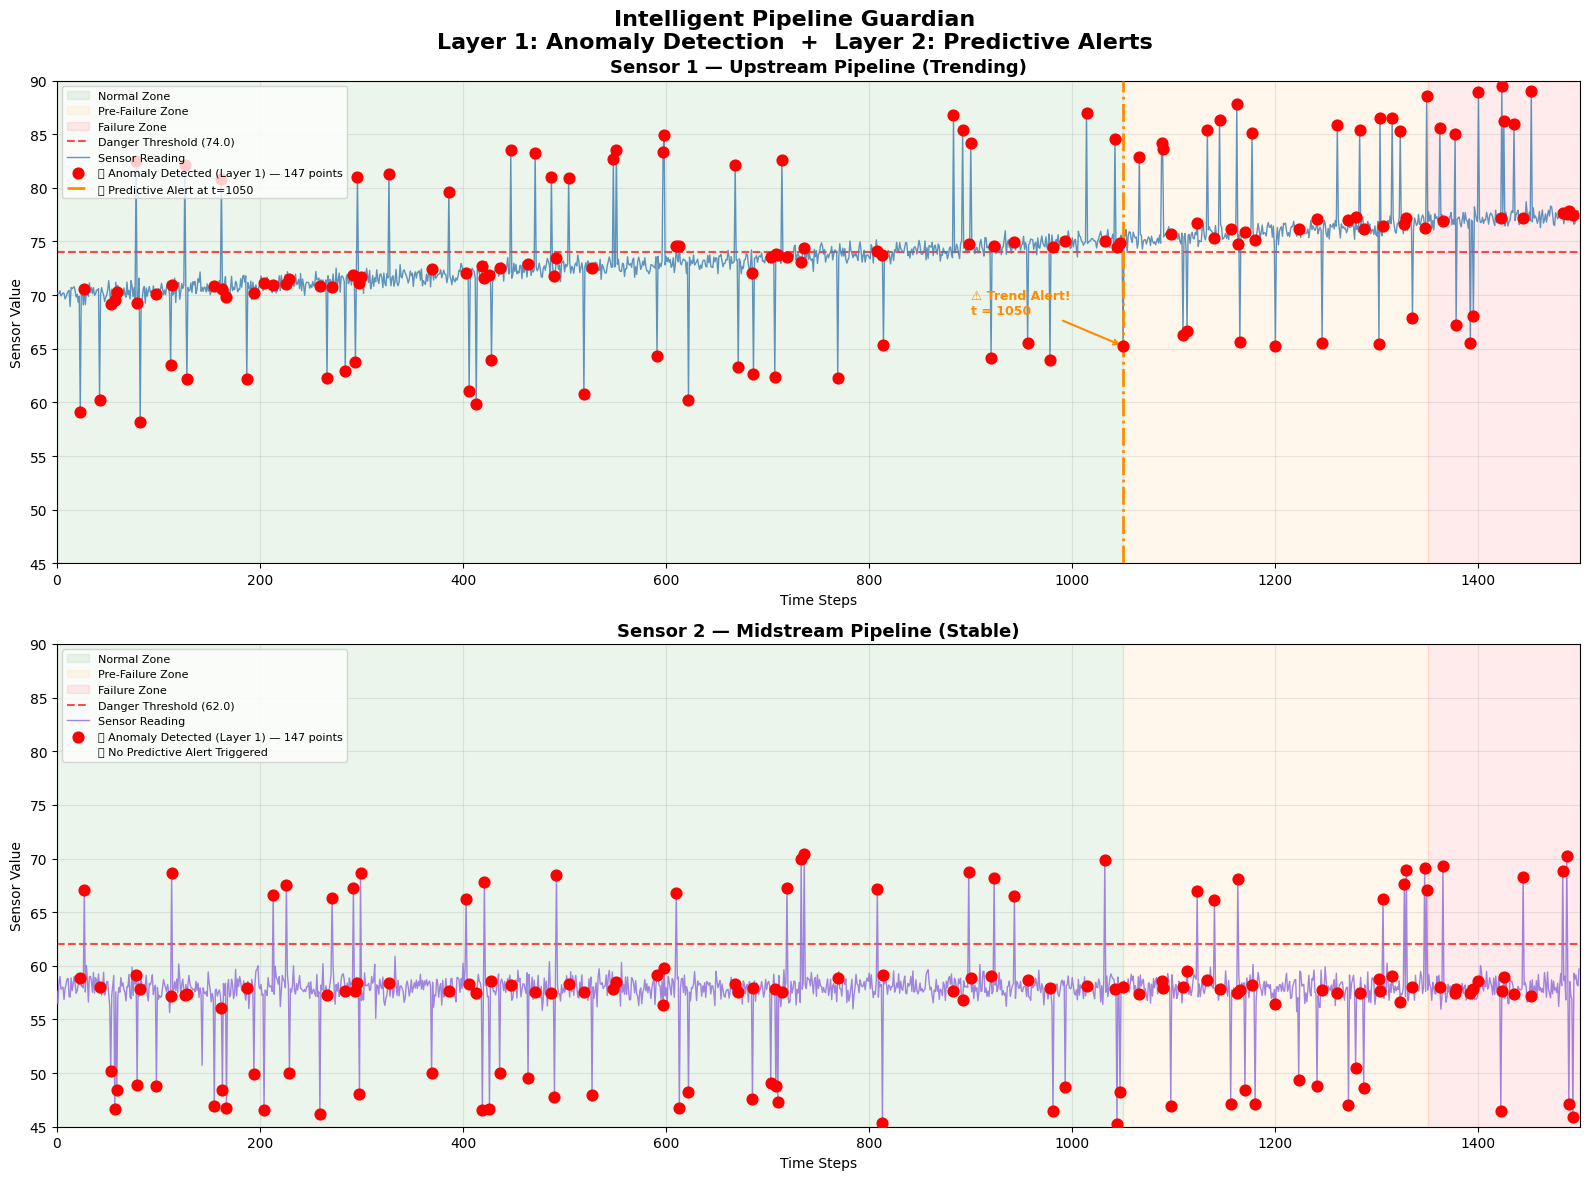

✅ Block 4 Complete — Chart saved as pipeline_guardian.png!

      INTELLIGENT PIPELINE GUARDIAN — SUMMARY

  Sensor 1:
    🎯 Danger Threshold     : 74.0
    🔮 Predictive alert at  : t = 1050
    ⏱️  Steps before end     : 450 steps early!

  Sensor 2:
    🎯 Danger Threshold     : 62.0
    ℹ️  No predictive alert triggered
    💡 Threshold may be too high for this sensor's range

  Layer 1 + Layer 2 = Complete Pipeline Protection!


In [4]:
# ─────────────────────────────────────────────
# BLOCK 4 — Visualise Layer 1 + Layer 2
#           Combined Chart — CLEAN REWRITE
# ─────────────────────────────────────────────

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ===========================================================
# CONFIGURATION — All settings in one place
# ===========================================================

# ✅ Sensor-specific danger thresholds (must match Block 3)
DANGER_THRESHOLD_S1 = 74.0
DANGER_THRESHOLD_S2 = 62.0

# ✅ Y-axis range — covers both sensor value ranges comfortably
SENSOR_Y_MIN = 45
SENSOR_Y_MAX = 90

# ✅ Zone boundaries as % of total time steps
NORMAL_END   = int(N_SAMPLES * 0.70)   # 0   → 70%  = Normal Zone
PRE_FAIL_END = int(N_SAMPLES * 0.90)   # 70% → 90%  = Pre-Failure Zone
                                        # 90% → 100% = Failure Zone

# ===========================================================
# BUILD UNIFIED DATAFRAME — single source of truth
# ===========================================================

df = pd.DataFrame({
    'Time'         : np.arange(N_SAMPLES),

    # Raw sensor readings from Block 1
    'Sensor1'      : sensor_1_data,
    'Sensor2'      : sensor_2_data,

    # Anomaly flags from Block 2 (True = anomaly detected)
    'Anomaly_S1'   : (data_for_model['is_anomaly'] == -1).values,
    'Anomaly_S2'   : (data_for_model['is_anomaly'] == -1).values,

    # Predictive alert flags from Block 3
    'Pred_Alert_S1': data_for_model['Pred_Alert_S1'].values,
    'Pred_Alert_S2': data_for_model['Pred_Alert_S2'].values,

    # Forecasted values from Block 3
    'Forecast_S1'  : data_for_model['Forecast_S1'].values,
    'Forecast_S2'  : data_for_model['Forecast_S2'].values,
})

# ===========================================================
# FIND FIRST PREDICTIVE ALERT FOR EACH SENSOR
# ===========================================================

s1_alerts     = df[df['Pred_Alert_S1'] == True]
s2_alerts     = df[df['Pred_Alert_S2'] == True]

first_pred_s1 = s1_alerts['Time'].min() if len(s1_alerts) > 0 else None
first_pred_s2 = s2_alerts['Time'].min() if len(s2_alerts) > 0 else None

print(f"  Sensor 1 — First predictive alert : {first_pred_s1}")
print(f"  Sensor 2 — First predictive alert : {first_pred_s2}")

# ===========================================================
# CHART CONFIGURATION — Parallel lists, one entry per sensor
# ===========================================================

chart_config = [
    {
        'sensor_col'       : 'Sensor1',
        'anomaly_col'      : 'Anomaly_S1',
        'pred_alert_col'   : 'Pred_Alert_S1',
        'first_pred'       : first_pred_s1,
        'danger_threshold' : DANGER_THRESHOLD_S1,
        'title'            : 'Sensor 1 — Upstream Pipeline (Trending)',
        'color'            : 'steelblue',
    },
    {
        'sensor_col'       : 'Sensor2',
        'anomaly_col'      : 'Anomaly_S2',
        'pred_alert_col'   : 'Pred_Alert_S2',
        'first_pred'       : first_pred_s2,
        'danger_threshold' : DANGER_THRESHOLD_S2,
        'title'            : 'Sensor 2 — Midstream Pipeline (Stable)',
        'color'            : 'mediumpurple',
    },
]

# ===========================================================
# PLOT
# ===========================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle(
    'Intelligent Pipeline Guardian\n'
    'Layer 1: Anomaly Detection  +  Layer 2: Predictive Alerts',
    fontsize=16, fontweight='bold', y=0.98
)

for ax, cfg in zip(axes, chart_config):

    sensor_col        = cfg['sensor_col']
    anomaly_col       = cfg['anomaly_col']
    danger_threshold  = cfg['danger_threshold']
    first_pred        = cfg['first_pred']

    # --- 1. Background zone shading ---
    ax.axvspan(0,            NORMAL_END,   alpha=0.08,
               color='green',  label='Normal Zone')
    ax.axvspan(NORMAL_END,   PRE_FAIL_END, alpha=0.08,
               color='orange', label='Pre-Failure Zone')
    ax.axvspan(PRE_FAIL_END, N_SAMPLES,    alpha=0.08,
               color='red',    label='Failure Zone')

    # --- 2. Danger threshold line ---
    ax.axhline(
        y=danger_threshold,
        color='red', linestyle='--',
        linewidth=1.5, alpha=0.7,
        label=f'Danger Threshold ({danger_threshold})'
    )

    # --- 3. Actual sensor readings ---
    ax.plot(
        df['Time'], df[sensor_col],
        color=cfg['color'], linewidth=1.0,
        alpha=0.85, label='Sensor Reading', zorder=3
    )

    # --- 4. Layer 1 — Detected anomaly points ---
    anomaly_rows = df[df[anomaly_col] == True]
    ax.scatter(
        anomaly_rows['Time'],
        anomaly_rows[sensor_col],
        color='red', s=60, zorder=5,
        label=f'🚨 Anomaly Detected (Layer 1) — {len(anomaly_rows)} points'
    )

    # --- 5. Layer 2 — First predictive alert marker ---
    if first_pred is not None and not pd.isna(first_pred):

        first_pred = int(first_pred)

        ax.axvline(
            x=first_pred,
            color='darkorange', linestyle='-.',
            linewidth=2, zorder=4,
            label=f'🔮 Predictive Alert at t={first_pred}'
        )

        # Safe annotation position
        sensor_val_at_pred = df[sensor_col].iloc[first_pred]
        annotation_x       = max(first_pred - 150, 10)
        annotation_y       = min(sensor_val_at_pred + 3, SENSOR_Y_MAX - 5)

        ax.annotate(
            f'⚠️ Trend Alert!\nt = {first_pred}',
            xy=(first_pred, sensor_val_at_pred),
            xytext=(annotation_x, annotation_y),
            fontsize=9, color='darkorange', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.5)
        )

    else:
        # No alert triggered — add info to legend
        ax.plot([], [], ' ',
                label='🔮 No Predictive Alert Triggered')

    # --- 6. Axis formatting ---
    ax.set_title(cfg['title'], fontsize=13, fontweight='bold')
    ax.set_xlabel('Time Steps', fontsize=10)
    ax.set_ylabel('Sensor Value', fontsize=10)
    ax.set_xlim(0, N_SAMPLES)
    ax.set_ylim(SENSOR_Y_MIN, SENSOR_Y_MAX)
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pipeline_guardian.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Block 4 Complete — Chart saved as pipeline_guardian.png!")

# ===========================================================
# SUMMARY REPORT
# ===========================================================

print("\n" + "="*55)
print("      INTELLIGENT PIPELINE GUARDIAN — SUMMARY")
print("="*55)

summary_config = [
    ('Sensor 1', first_pred_s1, DANGER_THRESHOLD_S1),
    ('Sensor 2', first_pred_s2, DANGER_THRESHOLD_S2),
]

for sensor_name, first_pred, threshold in summary_config:

    print(f"\n  {sensor_name}:")
    print(f"    🎯 Danger Threshold     : {threshold}")

    if first_pred is not None and not pd.isna(first_pred):
        steps_remaining = N_SAMPLES - int(first_pred)
        print(f"    🔮 Predictive alert at  : t = {int(first_pred)}")
        print(f"    ⏱️  Steps before end     : {steps_remaining} steps early!")
    else:
        print(f"    ℹ️  No predictive alert triggered")
        print(f"    💡 Threshold may be too high for this sensor's range")

print("\n" + "="*55)
print("  Layer 1 + Layer 2 = Complete Pipeline Protection!")
print("="*55)